In [1]:
import pandas as pd
import os

os.listdir()

['-1.14-windows.xml',
 '.anaconda',
 '.appletviewer',
 '.claude',
 '.claude.json',
 '.claude.json.backup.1771173948903',
 '.claude.json.backup.1771173948966',
 '.claude.json.backup.1771173948998',
 '.claude.json.backup.1771173949066',
 '.claude.json.backup.1771173949104',
 '.claude.json.corrupted.1771173948014',
 '.claude.json.corrupted.1771173948109',
 '.claude.json.corrupted.1771173948197',
 '.claude.json.corrupted.1771173948576',
 '.claude.json.corrupted.1771173948636',
 '.claude.json.corrupted.1771173948735',
 '.claude.json.corrupted.1771173948818',
 '.claude.json.corrupted.1771173948902',
 '.claude.json.corrupted.1771173949068',
 '.conda',
 '.condarc',
 '.continuum',
 '.copilot',
 '.cursor',
 '.dotnet',
 '.gitconfig',
 '.hotjava',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.ms-ad',
 '.nuget',
 '.spyder-py3',
 '.templateengine',
 '.vscode',
 '.vscode-shared',
 '3D Objects',
 'anaconda3',
 'AppData',
 'Application Data',
 'Contacts',
 'Cookies',
 

In [5]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df[['Order Date', 'Sales']].head()

,Order Date,Sales
0,2016-11-08,261.9600
1,2016-11-08,731.9400
2,2016-06-12,14.6200
3,2015-10-11,957.5775
4,2015-10-11,22.3680


In [13]:
print("Start Date:", df['Order Date'].min())
print("End Date:", df['Order Date'].max())

Start Date: 2014-01-03 00:00:00
End Date: 2017-12-30 00:00:00


In [15]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
).agg(
    Monthly_Revenue=('Sales', 'sum'),
    Order_Volume=('Order ID', 'nunique')
).reset_index()

monthly_sales

,Order Date,Monthly_Revenue,Order_Volume
0,2014-01,14236.8950,32
1,2014-02,4519.8920,28
2,2014-03,55691.0090,71
3,2014-04,28295.3450,66
4,2014-05,23648.2870,69
5,2014-06,34595.1276,66
6,2014-07,33946.3930,65
7,2014-08,27909.4685,72
8,2014-09,81777.3508,130
9,2014-10,31453.3930,78


In [17]:
top_3_months = monthly_sales.sort_values(
    by='Monthly_Revenue',
    ascending=False
).head(3)

top_3_months

,Order Date,Monthly_Revenue,Order_Volume
46,2017-11,118447.825,261
35,2016-12,96999.043,176
44,2017-09,87866.652,226


In [19]:
final_results = monthly_sales.copy()

final_results['Year'] = final_results['Order Date'].dt.year
final_results['Month'] = final_results['Order Date'].dt.month

final_results = final_results[
    ['Year', 'Month', 'Monthly_Revenue', 'Order_Volume']
]

final_results

,Year,Month,Monthly_Revenue,Order_Volume
0,2014,1,14236.8950,32
1,2014,2,4519.8920,28
2,2014,3,55691.0090,71
3,2014,4,28295.3450,66
4,2014,5,23648.2870,69
5,2014,6,34595.1276,66
6,2014,7,33946.3930,65
7,2014,8,27909.4685,72
8,2014,9,81777.3508,130
9,2014,10,31453.3930,78


In [21]:
final_results.to_csv("monthly_sales_results.csv", index=False)

print("Results saved successfully!")

Results saved successfully!


In [23]:
import os

os.path.exists("monthly_sales_results.csv")

True

In [25]:
sql_script = """
-- Task 6: Sales Trend Analysis Using Aggregations

-- 1. View sample records
SELECT *
FROM online_sales
LIMIT 10;

-- 2. Monthly revenue and order volume
SELECT
    strftime('%Y', "Order Date") AS year,
    strftime('%m', "Order Date") AS month,
    SUM("Sales") AS monthly_revenue,
    COUNT(DISTINCT "Order ID") AS order_volume
FROM online_sales
GROUP BY
    strftime('%Y', "Order Date"),
    strftime('%m', "Order Date")
ORDER BY
    year,
    month;

-- 3. Top 3 months by sales
SELECT
    strftime('%Y', "Order Date") AS year,
    strftime('%m', "Order Date") AS month,
    SUM("Sales") AS monthly_revenue
FROM online_sales
GROUP BY
    strftime('%Y', "Order Date"),
    strftime('%m', "Order Date")
ORDER BY monthly_revenue DESC
LIMIT 3;
"""

with open("sales_trend_analysis.sql", "w") as file:
    file.write(sql_script)

print("SQL script saved successfully!")

SQL script saved successfully!


In [27]:
import sqlite3

conn = sqlite3.connect("online_sales.db")

df.to_sql(
    "online_sales",
    conn,
    if_exists="replace",
    index=False
)

print("online_sales table created successfully!")

online_sales table created successfully!


In [29]:
query = """
SELECT *
FROM online_sales
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08 00:00:00,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08 00:00:00,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12 00:00:00,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [31]:
query = """
SELECT
    strftime('%Y', "Order Date") AS year,
    strftime('%m', "Order Date") AS month,
    SUM("Sales") AS monthly_revenue,
    COUNT(DISTINCT "Order ID") AS order_volume
FROM online_sales
GROUP BY
    strftime('%Y', "Order Date"),
    strftime('%m', "Order Date")
ORDER BY
    year,
    month;
"""

sql_results = pd.read_sql_query(query, conn)

sql_results

,year,month,monthly_revenue,order_volume
0,2014,01,14236.8950,32
1,2014,02,4519.8920,28
2,2014,03,55691.0090,71
3,2014,04,28295.3450,66
4,2014,05,23648.2870,69
5,2014,06,34595.1276,66
6,2014,07,33946.3930,65
7,2014,08,27909.4685,72
8,2014,09,81777.3508,130
9,2014,10,31453.3930,78


In [33]:
query = """
SELECT
    strftime('%Y', "Order Date") AS year,
    strftime('%m', "Order Date") AS month,
    SUM("Sales") AS monthly_revenue
FROM online_sales
GROUP BY
    strftime('%Y', "Order Date"),
    strftime('%m', "Order Date")
ORDER BY monthly_revenue DESC
LIMIT 3;
"""

top_3_sql = pd.read_sql_query(query, conn)

top_3_sql

,year,month,monthly_revenue
0,2017,11,118447.825
1,2016,12,96999.043
2,2017,09,87866.652


In [35]:
sql_results.to_csv("sql_monthly_sales_results.csv", index=False)
top_3_sql.to_csv("top_3_months.csv", index=False)

print("All SQL results saved successfully!")

All SQL results saved successfully!


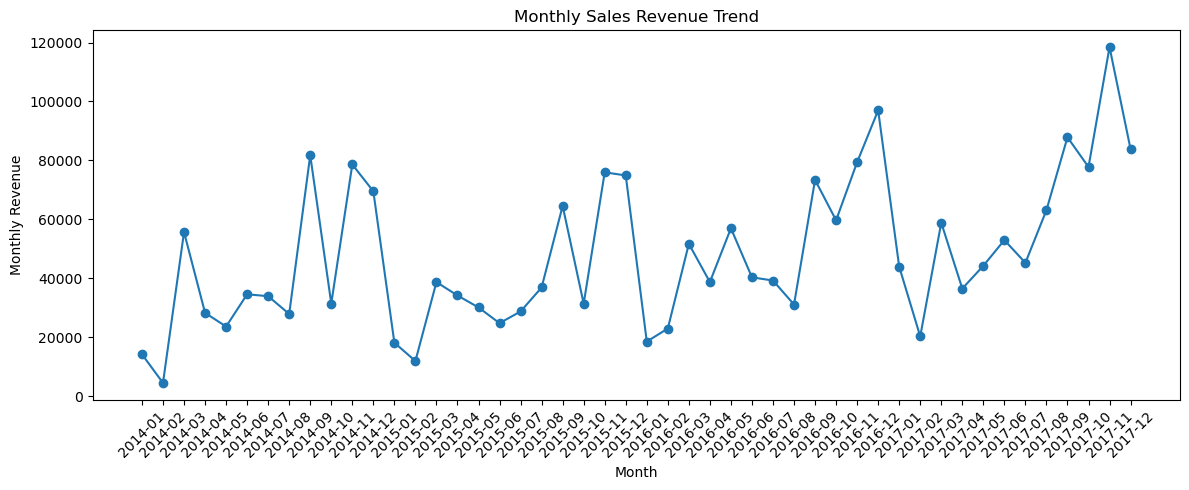

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    sql_results['year'].astype(str) + '-' + sql_results['month'].astype(str),
    sql_results['monthly_revenue'],
    marker='o'
)

plt.xlabel("Month")
plt.ylabel("Monthly Revenue")
plt.title("Monthly Sales Revenue Trend")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

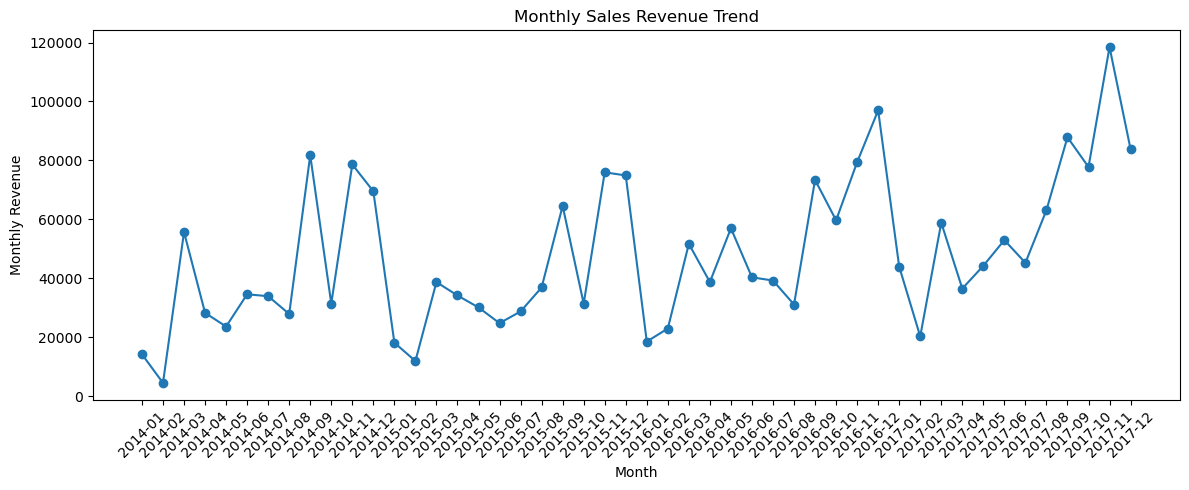

In [39]:
plt.figure(figsize=(12, 5))

plt.plot(
    sql_results['year'].astype(str) + '-' + sql_results['month'].astype(str),
    sql_results['monthly_revenue'],
    marker='o'
)

plt.xlabel("Month")
plt.ylabel("Monthly Revenue")
plt.title("Monthly Sales Revenue Trend")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("monthly_sales_trend.png", dpi=300)
plt.show()

In [41]:
readme = """
# Task 6 - Sales Trend Analysis Using Aggregations

## Objective
Analyze monthly revenue and order volume using SQL aggregation techniques.

## Dataset
Sample Superstore dataset.

## Tools Used
- Python
- Jupyter Notebook
- SQLite
- SQL
- Pandas
- Matplotlib

## Analysis Performed
1. Loaded and inspected the sales dataset.
2. Converted Order Date into date format.
3. Created an SQLite database and online_sales table.
4. Calculated monthly revenue using SUM().
5. Calculated monthly order volume using COUNT(DISTINCT Order ID).
6. Grouped sales by year and month.
7. Identified the top 3 months by revenue.
8. Created a monthly sales trend visualization.

## Key SQL Concepts
- GROUP BY
- SUM()
- COUNT(DISTINCT)
- ORDER BY
- LIMIT
- Date-based aggregation

## Files
- Task_6_Sales_Trend_Analysis.ipynb
- sales_trend_analysis.sql
- monthly_sales_results.csv
- sql_monthly_sales_results.csv
- top_3_months.csv
- monthly_sales_trend.png
- Sample - Superstore.csv
"""

with open("README.md", "w", encoding="utf-8") as file:
    file.write(readme)

print("README.md created successfully!")

README.md created successfully!


In [43]:
import os

for file in os.listdir():
    if file.endswith(('.ipynb', '.sql', '.csv', '.png', '.md', '.db')):
        print(file)

ecommerce.db
flower.png
monthly_sales_results.csv
monthly_sales_trend.png
online_sales.db
README.md
sales_trend_analysis.sql
Sample - Superstore.csv
sql_monthly_sales_results.csv
task3_ecommerce_analysis.sql
Task_3_SQL_Data_Analysis.ipynb
Task_5_Superstore_EDA.ipynb
Task_6_Sales_Trend_Analysis.ipynb
top_3_months.csv
Untitled.ipynb
Untitled1.ipynb
Untitled10.ipynb
Untitled11.ipynb
Untitled12.ipynb
Untitled13.ipynb
Untitled14.ipynb
Untitled15.ipynb
Untitled16.ipynb
Untitled17.ipynb
Untitled18.ipynb
Untitled19.ipynb
Untitled2.ipynb
Untitled20.ipynb
Untitled21.ipynb
Untitled22.ipynb
Untitled23.ipynb
Untitled24.ipynb
Untitled25.ipynb
Untitled26.ipynb
Untitled27.ipynb
Untitled28.ipynb
Untitled29.ipynb
Untitled3.ipynb
Untitled30.ipynb
Untitled31.ipynb
Untitled32.ipynb
Untitled33.ipynb
Untitled34.ipynb
Untitled35.ipynb
Untitled36.ipynb
Untitled37.ipynb
Untitled38.ipynb
Untitled39.ipynb
Untitled4.ipynb
Untitled5.ipynb
Untitled6.ipynb
Untitled7.ipynb
Untitled8.ipynb
Untitled9.ipynb


In [45]:
import os

files = [
    "Task_6_Sales_Trend_Analysis.ipynb",
    "sales_trend_analysis.sql",
    "monthly_sales_results.csv",
    "sql_monthly_sales_results.csv",
    "top_3_months.csv",
    "monthly_sales_trend.png",
    "README.md"
]

for file in files:
    print("✅" if os.path.exists(file) else "❌", file)

✅ Task_6_Sales_Trend_Analysis.ipynb
✅ sales_trend_analysis.sql
✅ monthly_sales_results.csv
✅ sql_monthly_sales_results.csv
✅ top_3_months.csv
✅ monthly_sales_trend.png
✅ README.md
